In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
matches = pd.concat([
    pd.read_csv(x, dtype=str)
    for x in sorted(glob.glob(os.path.expanduser("~/Box/dsi-core/11th-hour/good-food-purchasing/cgfp_usda_text_matches/*.csv")))
])
matches["cgfp_index"] = matches["cgfp_index"].astype(int)
matches["usda_index"] = matches["usda_index"].astype(int)
matches["encoding_similarity"] = matches["encoding_similarity"].astype(float)
matches["chatgpt_score"] = matches["chatgpt_score"].astype(float)
matches["Product GTIN or UPC"] = matches["Product GTIN or UPC"].apply(
    lambda x: f"{int(float(x.replace(' ', ''))):014d}" if isinstance(x, str) and x != "#REF!" else ""
)

In [3]:
matches

,cgfp_index,Product GTIN or UPC,Vendor,Brand Name,Product Type,Level of Processing,encoding_similarity,chatgpt_score,usda_index,usda_gtin_upc,usda_vendor,usda_brand,usda_product,usda_ingredients
0,0,,Sysco,NaN,FRUIT CUP PEACH COMDTY A422,Ultra-Processed,0.606015,1.0,1545855,00185043000351,National Food Group Inc.,Zee Zees,Diced Peaches Fruit Cup,"Peaches, Water, White Grape Juice Concentrate,..."
1,0,,Sysco,NaN,FRUIT CUP PEACH COMDTY A422,Ultra-Processed,0.606015,1.0,1549426,00185043000351,National Food Group Inc.,Zee Zees,Diced Peaches Fruit Cup,"Peaches, Water, White Grape Juice Concentrate,..."
2,0,,Sysco,NaN,FRUIT CUP PEACH COMDTY A422,Ultra-Processed,0.606015,1.0,1619966,00185043000351,National Food Group Inc.,Zee Zees,Diced Peaches Fruit Cup,"Peaches, Water, White Grape Juice Concentrate,..."
3,0,,Sysco,NaN,FRUIT CUP PEACH COMDTY A422,Ultra-Processed,0.606015,1.0,1631945,00185043000351,National Food Group Inc.,Zee Zees,Diced Peaches Fruit Cup,"Peaches, Water, White Grape Juice Concentrate,..."
4,0,,Sysco,NaN,FRUIT CUP PEACH COMDTY A422,Ultra-Processed,0.606015,1.0,1636711,00185043000351,National Food Group Inc.,Zee Zees,Diced Peaches Fruit Cup,"Peaches, Water, White Grape Juice Concentrate,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,88177,,Performance Foodservice,Culinary Secrets,Seasoning Everything Bagel,Culinary Ingredient,0.629594,0.1,1963622,10823056870345,Quality Bakeries LLC,Burry,"Bagel Everything, Thaw&Serve","Enriched Wheat Flour (Wheat Flour, Malted Barl..."
459,88177,,Performance Foodservice,Culinary Secrets,Seasoning Everything Bagel,Culinary Ingredient,0.629594,0.1,1970500,10823056870345,Quality Bakeries LLC,Burry,"Bagel Everything, Thaw&Serve","Enriched Wheat Flour (Wheat Flour, Malted Barl..."
460,90187,,Thurston Foods,HEINZ,SAUCE TARTAR PC (2151000),Ultra-Processed,0.642735,1.0,1720591,00074615000182,Silver Spring Foods Inc,Kelchner Food Products,Kelchner's Tartar Sauce 1oz PC,"Soybean Oil, Chopped Pickles, Water, Whole Egg..."
461,90187,,Thurston Foods,HEINZ,SAUCE TARTAR PC (2151000),Ultra-Processed,0.642735,1.0,1962051,00074615000182,Silver Spring Foods Inc,Kelchner Food Products,Kelchner's Tartar Sauce 1oz PC,"Soybean Oil, Chopped Pickles, Water, Whole Egg..."


In [4]:
len(matches)

989338

In [5]:
len(matches) / len(matches["cgfp_index"].drop_duplicates())

25.64513453263518

In [6]:
len(matches) / len(matches["usda_index"].drop_duplicates())

4.666028392208649

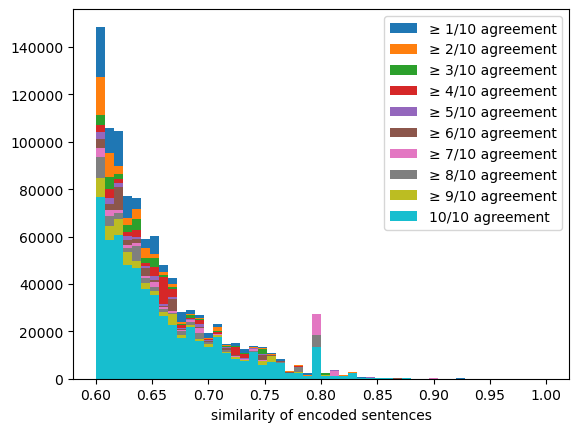

In [7]:
fig, ax = plt.subplots()

ax.hist(matches.query("chatgpt_score >= 0.1")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 1/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.2")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 2/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.3")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 3/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.4")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 4/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.5")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 5/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.6")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 6/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.7")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 7/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.8")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 8/10 agreement")
ax.hist(matches.query("chatgpt_score >= 0.9")["encoding_similarity"], bins=50, range=(0.6, 1), label="≥ 9/10 agreement")
ax.hist(matches.query("chatgpt_score >= 1.0")["encoding_similarity"], bins=50, range=(0.6, 1), label="10/10 agreement")

ax.set_xlabel("similarity of encoded sentences")
ax.legend()

None

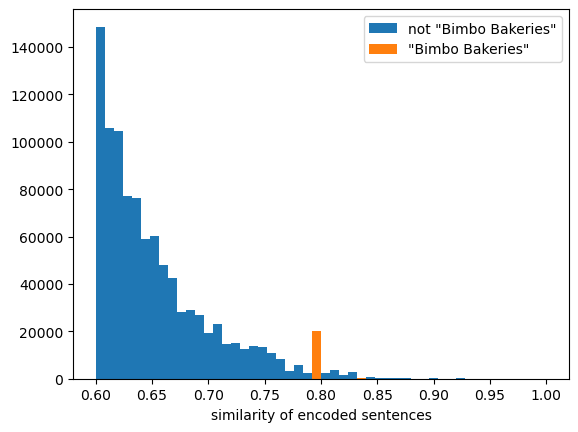

In [8]:
fig, ax = plt.subplots()

ax.hist(matches.query("Vendor != 'Bimbo Bakeries'")["encoding_similarity"], bins=50, range=(0.6, 1), label="not \"Bimbo Bakeries\"")
ax.hist(matches.query("Vendor == 'Bimbo Bakeries'")["encoding_similarity"], bins=50, range=(0.6, 1), label="\"Bimbo Bakeries\"")

ax.set_xlabel("similarity of encoded sentences")
ax.legend()

None

In [9]:
matches.query("Vendor == 'Bimbo Bakeries'")[[
    "Vendor", "Brand Name", "Product Type", "usda_vendor", "usda_brand", "usda_product"
]].drop_duplicates()

,Vendor,Brand Name,Product Type,usda_vendor,usda_brand,usda_product
54610,Bimbo Bakeries,NaN,NaN,"Bimbo Bakeries USA, Inc.",NaN,NaN
66154,Bimbo Bakeries,NaN,NaN,NaN,BIMBO,NaN
71329,Bimbo Bakeries,NaN,NaN,"Bimbo Bakeries USA, Inc.",BIMBO,NaN
72800,Bimbo Bakeries,NaN,NaN,BIMBO BAKERIES,NaN,NaN


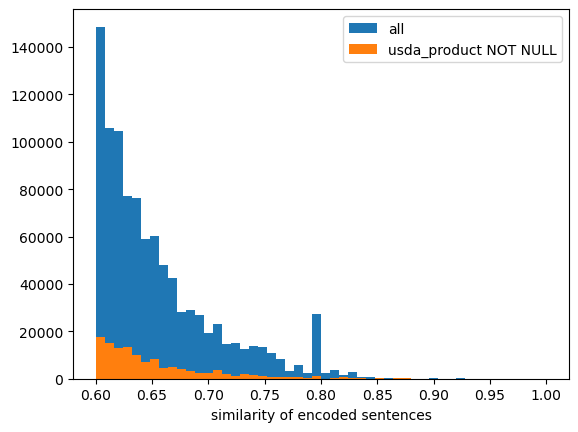

In [10]:
fig, ax = plt.subplots()

ax.hist(matches["encoding_similarity"], bins=50, range=(0.6, 1), label="all")
ax.hist(matches.query("usda_product.notna()")["encoding_similarity"], bins=50, range=(0.6, 1), label="usda_product NOT NULL")

ax.set_xlabel("similarity of encoded sentences")
ax.legend()

None

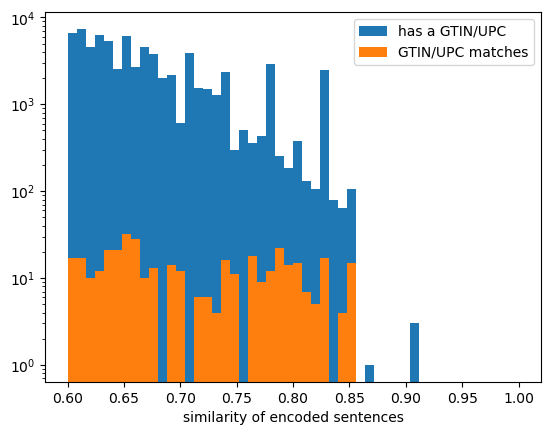

In [11]:
fig, ax = plt.subplots()

ax.hist(matches["encoding_similarity"][matches["Product GTIN or UPC"] != ""], bins=50, range=(0.6, 1), label="has a GTIN/UPC")
ax.hist(matches["encoding_similarity"][matches["Product GTIN or UPC"] == matches["usda_gtin_upc"]], bins=50, range=(0.6, 1), label="GTIN/UPC matches")

ax.set_yscale("log")
ax.set_xlabel("similarity of encoded sentences")
ax.legend()

None

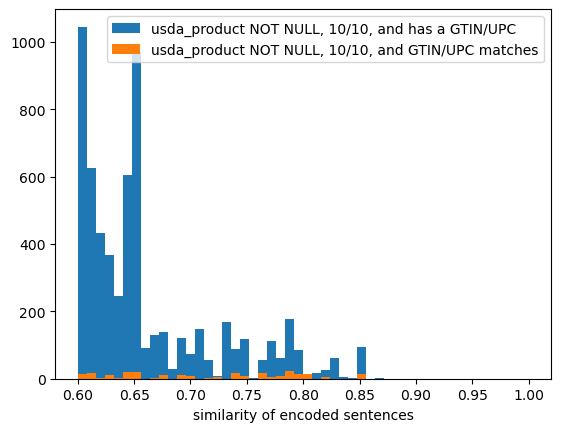

In [12]:
fig, ax = plt.subplots()

selected = matches.query("usda_product.notna() and chatgpt_score == 1")

ax.hist(selected["encoding_similarity"][selected["Product GTIN or UPC"] != ""], bins=50, range=(0.6, 1), label="usda_product NOT NULL, 10/10, and has a GTIN/UPC")
ax.hist(selected["encoding_similarity"][selected["Product GTIN or UPC"] == selected["usda_gtin_upc"]], bins=50, range=(0.6, 1), label="usda_product NOT NULL, 10/10, and GTIN/UPC matches")

ax.set_xlabel("similarity of encoded sentences")
ax.legend()

None

In [13]:
selected = matches.query("Vendor != 'Bimbo Bakeries' and usda_product.notna() and chatgpt_score == 1 and encoding_similarity > 0.655")

In [14]:
len(selected)

24356

In [15]:
len(selected["cgfp_index"].drop_duplicates()) / 90515

0.024283267966635363

In [16]:
len(selected) / len(selected["cgfp_index"].drop_duplicates())

11.08098271155596

In [17]:
len(selected) / len(selected["usda_index"].drop_duplicates())

2.7437197251323644

In [18]:
selected.take(np.random.permutation(len(selected)))[[
    "Vendor", "Brand Name", "Product Type", "usda_vendor", "usda_brand", "usda_product", "usda_ingredients"
]]

,Vendor,Brand Name,Product Type,usda_vendor,usda_brand,usda_product,usda_ingredients
31037,Gold Star Foods,NaN,CHEEZ-IT CRACKERS IW,Kellogg Company US,Kellogg's Cheez It,Cheez-It Crackers,"INGREDIENTS: WHOLE WHEAT FLOUR, ENRICHED FLOUR..."
31126,Pepsi,NaN,15.2OZ PL NJ ENRG ORG MGO 1/8,PepsiCo Inc. Brand Owner,Propel,Propel Zero Sgr Elctrlyts Mgo16.9Oz,"WATER, CITRIC ACID, SODIUM HEXAMETAPHOSPHATE (..."
6613,Keefe Commissary,NaN,KELLOGGS_TOASTER PASTRIES_BROWN SUGAR CINNAMON...,Kellogg Company US,Kellogg's Pop-Tarts,Toaster Pastries,"ENRICHED FLOUR (WHEAT FLOUR, NIACIN, REDUCED I..."
18035,Sysco,NaN,SODA GINGER ALE,POLAR BEVERAGES,POLAR,GINGER ALE,"Carbonated Water, High Fructose Corn Syrup, Ci..."
120389,Sysco,KELLOGG'S,CEREAL RAISIN BRAN (BOWL),WK KELLOGG CO,Kellogg's,Raisin Bran Cereal,"INGREDIENTS: WHOLE GRAIN WHEAT, RAISINS, WHEA..."
...,...,...,...,...,...,...,...
39808,Sysco,NaN,CEREAL FROOT LOOPS INDIV BOX,Kellogg Company US,Kellogg's,Froot Loops Cereal,INGREDIENTS: CORN FLOUR BLEND (whole grain yel...
93477,US Foods,KELLOGGS CHEEZ IT / KELLANOVA,"CRACKER, CHEESE CHEDDAR SQUARE SALTED BOX ORIG...",Kellogg Company US,Kellogg's Cheez It,Cheez-It Crackers,"INGREDIENTS: ENRICHED FLOUR (wheat flour, niac..."
21097,Gold Star Foods,NaN,RF CHEEZ-IT CRACKERS IW,Kellogg Company US,Kellogg's Cheez It,Cheez-It Crackers,"ENRICHED FLOUR (wheat flour, niacin, reduced i..."
65349,S&W Wholesale Foods,NaN,RICE PARBOILED 50LB LONG GRAIN,Riceland Foods,Chefway,RICE BRN US#1 LONG PARBOILED PKG-24,Parboiled Long Grain Brown Rice


In [19]:
cgfp = pd.read_csv(
    "~/Box/dsi-core/11th-hour/good-food-purchasing/CONFIDENTIAL_GFPP Product Attribute List_8.26.25.csv",
    dtype=str,
)

In [20]:
cgfp["Vendor"].value_counts()[:20]

Vendor
US Foods                    15693
Sysco                       13091
Aramark                      3181
Morrison Healthcare          2847
Sodexo                       2840
Driscoll                     2789
Gold Star Foods              2035
Baldor Foods                 2026
Shamrock Foods               1811
Labatt Foods                 1688
Thurston Foods               1526
SYSCO                        1241
Gordon Food Service          1211
Performance Food Group       1160
Hansen                       1031
Performance Foodservice       959
Performance Food Service      783
S. Bertram                    743
Cardinal Foods                707
Sysco Denver                  664
Name: count, dtype: int64

In [21]:
np.cumsum((cgfp["Vendor"].value_counts() / len(cgfp))[:20])

Vendor
US Foods                    0.173428
Sysco                       0.318101
Aramark                     0.353255
Morrison Healthcare         0.384718
Sodexo                      0.416104
Driscoll                    0.446926
Gold Star Foods             0.469415
Baldor Foods                0.491805
Shamrock Foods              0.511819
Labatt Foods                0.530474
Thurston Foods              0.547338
SYSCO                       0.561053
Gordon Food Service         0.574436
Performance Food Group      0.587256
Hansen                      0.598650
Performance Foodservice     0.609248
Performance Food Service    0.617901
S. Bertram                  0.626112
Cardinal Foods              0.633925
Sysco Denver                0.641263
Name: count, dtype: float64